In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zhiqingcui/awidclsr")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'awidclsr' dataset.
Path to dataset files: /kaggle/input/awidclsr


Loading a sample of the raw dataset...
Cleaning raw features for correlation calculation...
Generating heatmap for 151 numeric features...


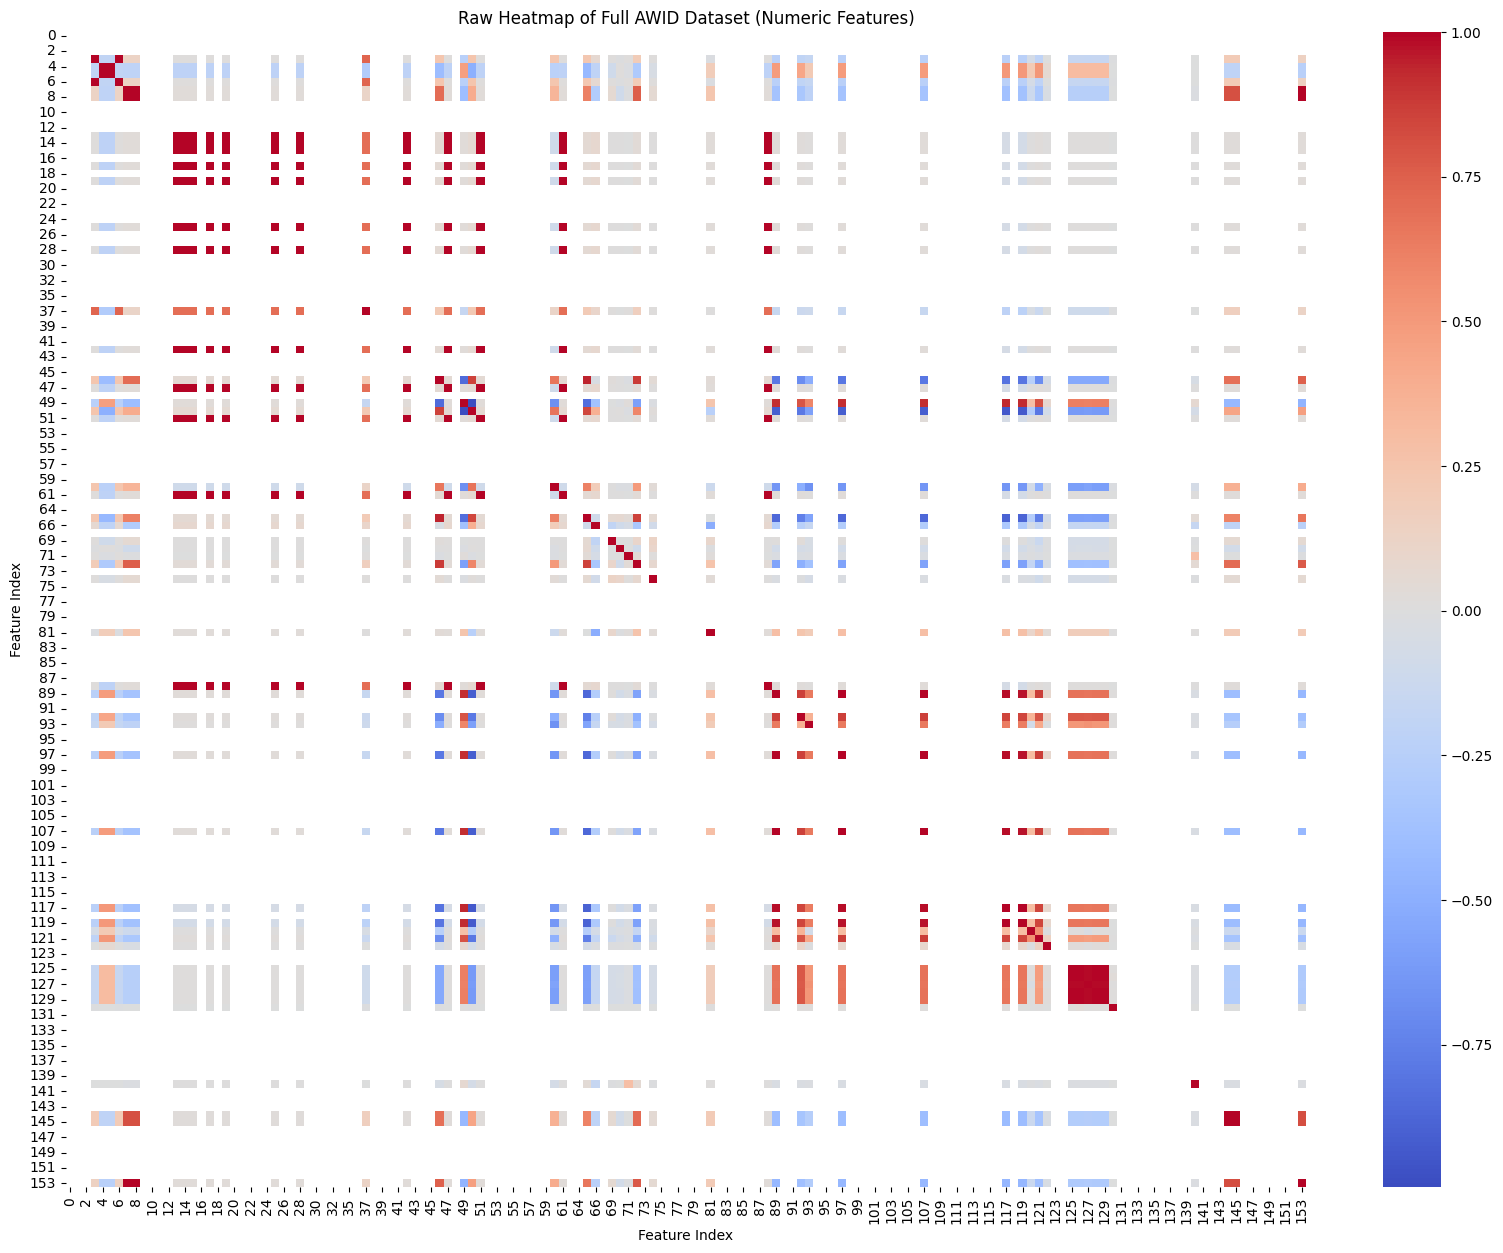

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: LOAD A SAMPLE OF THE FULL DATASET ---
# We load a sample to prevent memory crashes while maintaining statistical relevance [cite: 304]
print("Loading a sample of the raw dataset...")
df_raw_sample = pd.read_csv(train_path, header=None, nrows=50000, low_memory=False)

# --- STEP 2: RAW PREPROCESSING FOR VISUALIZATION ---
def raw_prep_for_heatmap(df):
    # Drop the label column so we only look at feature relationships
    features = df.iloc[:, :-1].copy()

    # Replace symbols with 0 for calculation [cite: 248-250]
    features.replace('?', 0, inplace=True)

    # Convert everything to numeric, forcing errors to NaN
    # We then drop columns that are entirely NaN (non-numeric garbage strings)
    features = features.apply(pd.to_numeric, errors='coerce')
    features.dropna(axis=1, how='all', inplace=True)

    return features

print("Cleaning raw features for correlation calculation...")
features_clean = raw_prep_for_heatmap(df_raw_sample)

# --- STEP 3: GENERATE THE HEATMAP ---
print(f"Generating heatmap for {features_clean.shape[1]} numeric features...")

# Calculate Pearson correlation
corr_matrix = features_clean.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False) # Annot=False because 154 columns is too many for text

plt.title('Raw Heatmap of Full AWID Dataset (Numeric Features)')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

In [7]:
import pandas as pd

# Unique feature names based on Table 3, duplicates are handled with suffixes
unique_feature_names = [
    "frame.interface_id", "frame.dlt", "frame.offset_shift", "frame.time_epoch", "frame.time_delta",
    "frame.time_delta_displayed", "frame.time_relative", "frame.len", "frame.cap_len", "frame.marked",
    "frame.ignored", "radiotap.version_1", "radiotap.pad_1", "radiotap.length_1", "radiotap.present.tsft_1",
    "radiotap.present.flags_1", "radiotap.present.rate_1", "radiotap.present.channel_1", "radiotap.present.fhss_1",
    "radiotap.present.dbm_antsignal_1", "radiotap.present.dbm_antnoise_1", "radiotap.present.lock_quality_1",
    "radiotap.present.tx_attenuation_1", "radiotap.present.db_tx_attenuation_1", "radiotap.present.dbm_tx_power_1",
    "radiotap.present.antenna_1", "wlan_mgt.fixed.capabilities.ess", "wlan_mgt.fixed.capabilities.ibss",
    "wlan_mgt.fixed.capabilities.cfpoll.ap", "wlan_mgt.fixed.capabilities.privacy",
    "wlan_mgt.fixed.capabilities.preamble", "wlan_mgt.fixed.capabilities.pbce",
    "wlan_mgt.fixed.capabilities.agility", "wlan_mgt.fixed.capabilities.spec_man",
    "wlan_mgt.fixed.capabilities.short_slot_time", "wlan_mgt.fixed.capabilities.apsd",
    "wlan_mgt.fixed.capabilities.radio_measurement", "wlan_mgt.fixed.capabilities.dsss_ofdm",
    "wlan_mgt.fixed.capabilities.del_blk_ack", "wlan_mgt.fixed.capabilities.imm_blk_ack",
    "wlan_mgt.fixed.listen_ival", "wlan_mgt.fixed.current_ap", "wlan_mgt.fixed.status_code",
    "wlan_mgt.fixed.timestamp", "wlan_mgt.fixed.beacon", "wlan_mgt.fixed.aid", "wlan_mgt.fixed.reason_code",
    "wlan_mgt.fixed.auth.alg", "wlan_mgt.fixed.auth_seq", "wlan_mgt.fixed.category_code",
    "wlan_mgt.fixed.htact", "wlan_mgt.fixed.chanwidth", "wlan_mgt.fixed.fragment", "wlan_mgt.fixed.sequence_1",
    "wlan_mgt.tagged.all", "wlan_mgt.ssid", "wlan_mgt.ds.current_channel", "wlan_mgt.tim.dtim_count",
    "wlan_mgt.tim.dtim_period", "wlan_mgt.tim.bmapctl.multicast", "wlan_mgt.tim.bmapctl.offset",
    "wlan_mgt.country_info.environment", "wlan_mgt.rsn.version", "wlan_mgt.rsn.ges.type",
    "wlan_mgt.rsn.pcs.count", "wlan_mgt.rsn.akms.count", "wlan_mgt.rsn.akms.type_1",
    "wlan_mgt.rsn.capabilities.preauth", "wlan_mgt.rsn.capabilities.no_pairwise",
    "wlan_mgt.rsn.capabilities.ptksa_replay_counter", "wlan_mgt.rsn.capabilities.gtksa_replay_counter",
    "wlan_mgt.rsn.capabilities.mfpr", "wlan_mgt.rsn.capabilities.mfpc", "wlan_mgt.rsn.capabilities.peerkey",
    "wlan_mgt.teprep.trsmt_pow", "wlan_mgt.tcprep.link_mrg", "wlan.wep.iv", "wlan.wep.key", "wlan.wep.icv",
    "wlan.tkip.extiv", "wlan.ccmp.extiv", "wlan.qos.tid", "wlan.qos.priority", "wlan.qos.eosp", "wlan.qos.ack",
    "wlan.qos.amsdupresent", "wlan.qos.buf_state_indicated_1", "wlan.qos.bit4", "wlan.qos.txop_dur_req",
    "wlan.duration", "data.len", "wlan.sa", "wlan.bssid", "wlan.frag", "wlan.seq", "wlan.bar.type",
    "wlan.ba.control.ackpolicy", "wlan.ba.control.multitid", "wlan.ba.control.cbitmap",
    "wlan.bar.compressed.tidinfo", "wlan.ba.bm", "wlan.fcs_good", "radiotap.version_2", "radiotap.pad_2",
    "radiotap.length_2", "radiotap.present.tsft_2", "radiotap.present.flags_2", "radiotap.present.rate_2",
    "radiotap.present.channel_2", "radiotap.present.fhss_2", "radiotap.present.dbm_antsignal_2",
    "radiotap.present.dbm_antnoise_2", "radiotap.present.lock_quality_2", "radiotap.present.tx_attenuation_2",
    "radiotap.present.db_tx_attenuation_2", "radiotap.present.dbm_tx_power_2", "radiotap.present.antenna_2",
    "radiotap.present.db_antsignal_2", "radiotap.present.db_antnoise_2", "radiotap.present.rxflags",
    "radiotap.present.xchannel", "radiotap.present.mcs", "radiotap.present.ampdu", "radiotap.present.vht",
    "radiotap.present.reserved", "radiotap.present.rtap_ns", "radiotap.present.vendor_ns", "radiotap.present.ext",
    "radiotap.mactime", "radiotap.flags.cfp", "radiotap.flags.preamble", "radiotap.flags.wep", "radiotap.flags.frag",
    "radiotap.flags.fcs", "radiotap.flags.datapad", "radiotap.flags.badfcs", "radiotap.flags.shortgi",
    "radiotap.datarate", "radiotap.channel.freq", "radiotap.channel.type.turbo", "radiotap.channel.type.cck",
    "radiotap.channel.type.ofdm", "radiotap.channel.type.2ghz", "radiotap.channel.type.5ghz",
    "radiotap.channel.type.passive", "radiotap.channel.type.dynamic", "radiotap.channel.type.gfsk",
    "radiotap.channel.type.gsm", "radiotap.channel.type.sturbo", "radiotap.channel.type.half",
    "radiotap.channel.type.quarter", "radiotap.dbm_antsignal", "radiotap.antenna", "radiotap.rxflags.badplcp",
    "wlan.fc.type_subtype", "wlan.fc.version", "wlan.fc.type", "wlan.fc.subtype", "wlan.fc.ds", "wlan.fc.frag",
    "wlan.fc.retry", "wlan.fc.pwrmgt", "wlan.fc.moredata", "wlan.fc.protected", "wlan.fc.order", "wlan.ra",
    "wlan.da", "class"
]

# Use the path confirmed in your Google Colab instance
train_path = '/kaggle/input/awidclsr/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'

print("Phase 1: Loading Dataset Preview with Unique Headers...")
# Loading first 10 rows for a quick check
df_preview = pd.read_csv(train_path, header=None, names=unique_feature_names, nrows=10, low_memory=False)

# Configure Pandas to show all columns for the preview
pd.set_option('display.max_columns', None)

print("\n--- AWID Dataset Preview (Unique Attribute Headers) ---")
display(df_preview)

Phase 1: Loading Dataset Preview with Unique Headers...

--- AWID Dataset Preview (Unique Attribute Headers) ---


,frame.interface_id,frame.dlt,frame.offset_shift,frame.time_epoch,frame.time_delta,frame.time_delta_displayed,frame.time_relative,frame.len,frame.cap_len,frame.marked,frame.ignored,radiotap.version_1,radiotap.pad_1,radiotap.length_1,radiotap.present.tsft_1,radiotap.present.flags_1,radiotap.present.rate_1,radiotap.present.channel_1,radiotap.present.fhss_1,radiotap.present.dbm_antsignal_1,radiotap.present.dbm_antnoise_1,radiotap.present.lock_quality_1,radiotap.present.tx_attenuation_1,radiotap.present.db_tx_attenuation_1,radiotap.present.dbm_tx_power_1,radiotap.present.antenna_1,wlan_mgt.fixed.capabilities.ess,wlan_mgt.fixed.capabilities.ibss,wlan_mgt.fixed.capabilities.cfpoll.ap,wlan_mgt.fixed.capabilities.privacy,wlan_mgt.fixed.capabilities.preamble,wlan_mgt.fixed.capabilities.pbce,wlan_mgt.fixed.capabilities.agility,wlan_mgt.fixed.capabilities.spec_man,wlan_mgt.fixed.capabilities.short_slot_time,wlan_mgt.fixed.capabilities.apsd,wlan_mgt.fixed.capabilities.radio_measurement,wlan_mgt.fixed.capabilities.dsss_ofdm,wlan_mgt.fixed.capabilities.del_blk_ack,wlan_mgt.fixed.capabilities.imm_blk_ack,wlan_mgt.fixed.listen_ival,wlan_mgt.fixed.current_ap,wlan_mgt.fixed.status_code,wlan_mgt.fixed.timestamp,wlan_mgt.fixed.beacon,wlan_mgt.fixed.aid,wlan_mgt.fixed.reason_code,wlan_mgt.fixed.auth.alg,wlan_mgt.fixed.auth_seq,wlan_mgt.fixed.category_code,wlan_mgt.fixed.htact,wlan_mgt.fixed.chanwidth,wlan_mgt.fixed.fragment,wlan_mgt.fixed.sequence_1,wlan_mgt.tagged.all,wlan_mgt.ssid,wlan_mgt.ds.current_channel,wlan_mgt.tim.dtim_count,wlan_mgt.tim.dtim_period,wlan_mgt.tim.bmapctl.multicast,wlan_mgt.tim.bmapctl.offset,wlan_mgt.country_info.environment,wlan_mgt.rsn.version,wlan_mgt.rsn.ges.type,wlan_mgt.rsn.pcs.count,wlan_mgt.rsn.akms.count,wlan_mgt.rsn.akms.type_1,wlan_mgt.rsn.capabilities.preauth,wlan_mgt.rsn.capabilities.no_pairwise,wlan_mgt.rsn.capabilities.ptksa_replay_counter,wlan_mgt.rsn.capabilities.gtksa_replay_counter,wlan_mgt.rsn.capabilities.mfpr,wlan_mgt.rsn.capabilities.mfpc,wlan_mgt.rsn.capabilities.peerkey,wlan_mgt.teprep.trsmt_pow,wlan_mgt.tcprep.link_mrg,wlan.wep.iv,wlan.wep.key,wlan.wep.icv,wlan.tkip.extiv,wlan.ccmp.extiv,wlan.qos.tid,wlan.qos.priority,wlan.qos.eosp,wlan.qos.ack,wlan.qos.amsdupresent,wlan.qos.buf_state_indicated_1,wlan.qos.bit4,wlan.qos.txop_dur_req,wlan.duration,data.len,wlan.sa,wlan.bssid,wlan.frag,wlan.seq,wlan.bar.type,wlan.ba.control.ackpolicy,wlan.ba.control.multitid,wlan.ba.control.cbitmap,wlan.bar.compressed.tidinfo,wlan.ba.bm,wlan.fcs_good,radiotap.version_2,radiotap.pad_2,radiotap.length_2,radiotap.present.tsft_2,radiotap.present.flags_2,radiotap.present.rate_2,radiotap.present.channel_2,radiotap.present.fhss_2,radiotap.present.dbm_antsignal_2,radiotap.present.dbm_antnoise_2,radiotap.present.lock_quality_2,radiotap.present.tx_attenuation_2,radiotap.present.db_tx_attenuation_2,radiotap.present.dbm_tx_power_2,radiotap.present.antenna_2,radiotap.present.db_antsignal_2,radiotap.present.db_antnoise_2,radiotap.present.rxflags,radiotap.present.xchannel,radiotap.present.mcs,radiotap.present.ampdu,radiotap.present.vht,radiotap.present.reserved,radiotap.present.rtap_ns,radiotap.present.vendor_ns,radiotap.present.ext,radiotap.mactime,radiotap.flags.cfp,radiotap.flags.preamble,radiotap.flags.wep,radiotap.flags.frag,radiotap.flags.fcs,radiotap.flags.datapad,radiotap.flags.badfcs,radiotap.flags.shortgi,radiotap.datarate,radiotap.channel.freq,radiotap.channel.type.turbo,radiotap.channel.type.cck,radiotap.channel.type.ofdm,radiotap.channel.type.2ghz,radiotap.channel.type.5ghz,radiotap.channel.type.passive,radiotap.channel.type.dynamic,radiotap.channel.type.gfsk,radiotap.channel.type.gsm,radiotap.channel.type.sturbo,radiotap.channel.type.half,radiotap.channel.type.quarter,radiotap.dbm_antsignal,radiotap.antenna,radiotap.rxflags.badplcp,wlan.fc.type_subtype,wlan.fc.version,wlan.fc.type,wlan.fc.subtype,wlan.fc.ds,wlan.fc.frag,wlan.fc.retry,wlan.fc.pwrmgt,wlan.fc.moredata,wlan.fc.protected,wlan.fc.order,wlan.ra,wlan.da,class

In [8]:
import kagglehub
import os

# Download the AWID dataset
path = kagglehub.dataset_download("zhiqingcui/awidclsr")

print("Path to dataset files:", path)

# List the files to see what you're working with
print("Files in dataset:", os.listdir(path))

Using Colab cache for faster access to the 'awidclsr' dataset.
Path to dataset files: /kaggle/input/awidclsr
Files in dataset: ['AWID-CLS-R-Tst', 'AWID-CLS-R-Trn']


In [9]:
import os

# This lists everything in the folder kagglehub created
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/awidclsr/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1
/kaggle/input/awidclsr/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1


In [3]:
import zipfile

# Find the zip file in your path
zip_files = [f for f in os.listdir(path) if f.endswith('.zip')]

if zip_files:
    for z in zip_files:
        with zipfile.ZipFile(os.path.join(path, z), 'r') as zip_ref:
            zip_ref.extractall(path)
            print(f"Extracted: {z}")
else:
    print("No zip files found, checking for CSVs...")

No zip files found, checking for CSVs...


In [ ]:
# Updated for the Reduced Dataset (155 columns total)
# 154 is the 'class' label at the very end
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

df = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)

# Assign names based on Table 3
df.columns = [
    'frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
    'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
    'wlan_ds', 'wlan_ra', 'wlan_da', 'label'
]

In [ ]:
# Reshape for CNN: (Samples, Features, 1) [cite: 301]
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("Final shape for CNN input:", X_reshaped.shape)

Final shape for CNN input: (1795575, 13, 1)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# --- PHASE 1: DATA LOADING ---
train_path = '/kaggle/input/awidclsr/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/kaggle/input/awidclsr/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

# 13 pivotal features + class label based on the paper's feature selection [cite: 21]
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

print("Loading Dataset...")
df_train = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=pivotal_indices, low_memory=False)

cols = ['frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
        'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
        'wlan_ds', 'wlan_ra', 'wlan_da', 'label']
df_train.columns = cols
df_test.columns = cols

# --- PHASE 2: PREPROCESSING & SCALING ---
def preprocess_for_cnn(df):
    features = df.drop('label', axis=1).copy()
    label = df['label'].copy()

    # Replace errors and nulls as per methodology [cite: 247-250]
    features.replace('?', np.nan, inplace=True)
    features.fillna('0', inplace=True)

    # Convert Hexadecimal to Integer [cite: 251-252]
    hex_cols = ['wlan_type', 'wlan_ds', 'wlan_ra', 'wlan_da', 'rtap_flags', 'rtap_tsft']
    for col in hex_cols:
        features[col] = features[col].apply(lambda x: int(str(x), 16) if 'x' in str(x) else x)
        features[col] = features[col].apply(lambda x: int(str(x).replace(':', ''), 16) if ':' in str(x) else x)

    features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
    return features, label

print("Cleaning data and applying Standard Scaling...")
X_train_raw, y_train_raw = preprocess_for_cnn(df_train)
X_test_raw, y_test_raw = preprocess_for_cnn(df_test)

# Standard Scaling ensures features have equal weight for the CNN [cite: 253-255]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Label Encoding [cite: 256-258]
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw.astype(str))
y_test = le.transform(y_test_raw.astype(str))
target_names = [str(c) for c in le.classes_]

# Reshape to 3D for CNN input (Samples, Features, 1) [cite: 301]
X_train = X_train.reshape(X_train.shape[0], 13, 1)
X_test = X_test.reshape(X_test.shape[0], 13, 1)

# --- PHASE 3: BALANCING THE CLASSES ---
# Calculate weights to fix the "0% accuracy on attacks" issue
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(f"Class Weights Calculated: {class_weight_dict}")

# --- PHASE 4: CNN ARCHITECTURE (TABLE 6) ---
print("Building CNN Architecture...")
model = models.Sequential([
    Input(shape=(13, 1)),
    layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2), # Dropout to prevent overfitting [cite: 332]
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- PHASE 5: TRAINING & EVALUATION ---
print("Training with Early Stopping and Class Weights...")
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(X_train, y_train,
          epochs=10,
          batch_size=2048,
          validation_split=0.2,
          class_weight=class_weight_dict, # Apply weights here
          callbacks=[early_stop])

print("\nFinal Model Evaluation:")
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=target_names))

Loading Dataset...
Cleaning data and applying Standard Scaling...
Class Weights Calculated: {0: np.float64(9.258595619173336), 1: np.float64(9.251344750834672), 2: np.float64(6.866023493782407), 3: np.float64(0.2748570282698278)}
Building CNN Architecture...
Training with Early Stopping and Class Weights...
Epoch 1/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7987 - loss: 0.3441 - val_accuracy: 0.8900 - val_loss: 0.4502
Epoch 2/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8400 - loss: 0.1747 - val_accuracy: 0.8882 - val_loss: 0.7735
Epoch 3/10
702/702 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8549 - loss: 0.1397 - val_accuracy: 0.8915 - val_loss: 0.9361

Final Model Evaluation:
17989/17989 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step
               precision    recall  f1-score   support

     flooding       0.00      0.00      0.00      8097
impersonation       0.00      0.00      0.00     20079
    injection       0.33      0.83      0.47     16682
       normal

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ENHANCED CNN INTRUSION DETECTION SYSTEM

📊 Loading Dataset...
Training samples: 1,795,575
Testing samples: 575,643

🧹 Cleaning data and applying Standard Scaling...

Class Distribution in Training Set:
  flooding       :   48,484 (2.70%)
  impersonation  :   48,522 (2.70%)
  injection      :   65,379 (3.64%)
  normal         : 1,633,190 (90.96%)

STRATEGY 1: CLASS WEIGHTS (Current Approach)
Class Weights:
  flooding       : 9.26
  impersonation  : 9.25
  injection      : 6.87
  normal         : 0.27

STRATEGY 2: SMOTE Oversampling
After SMOTE - Class Distribution:
  flooding       : 1,633,190
  impersonation  : 1,633,190
  injection      : 1,633,190
  normal         : 1,633,190

STRATEGY 3: Focal Loss Implementation

STRATEGY 1: Class Weights

📈 Training with class_weights...



STRATEGY 2: SMOTE + Class Weights

📈 Training with smote...



STRATEGY 3: Focal Loss

📈 Training with focal_loss...


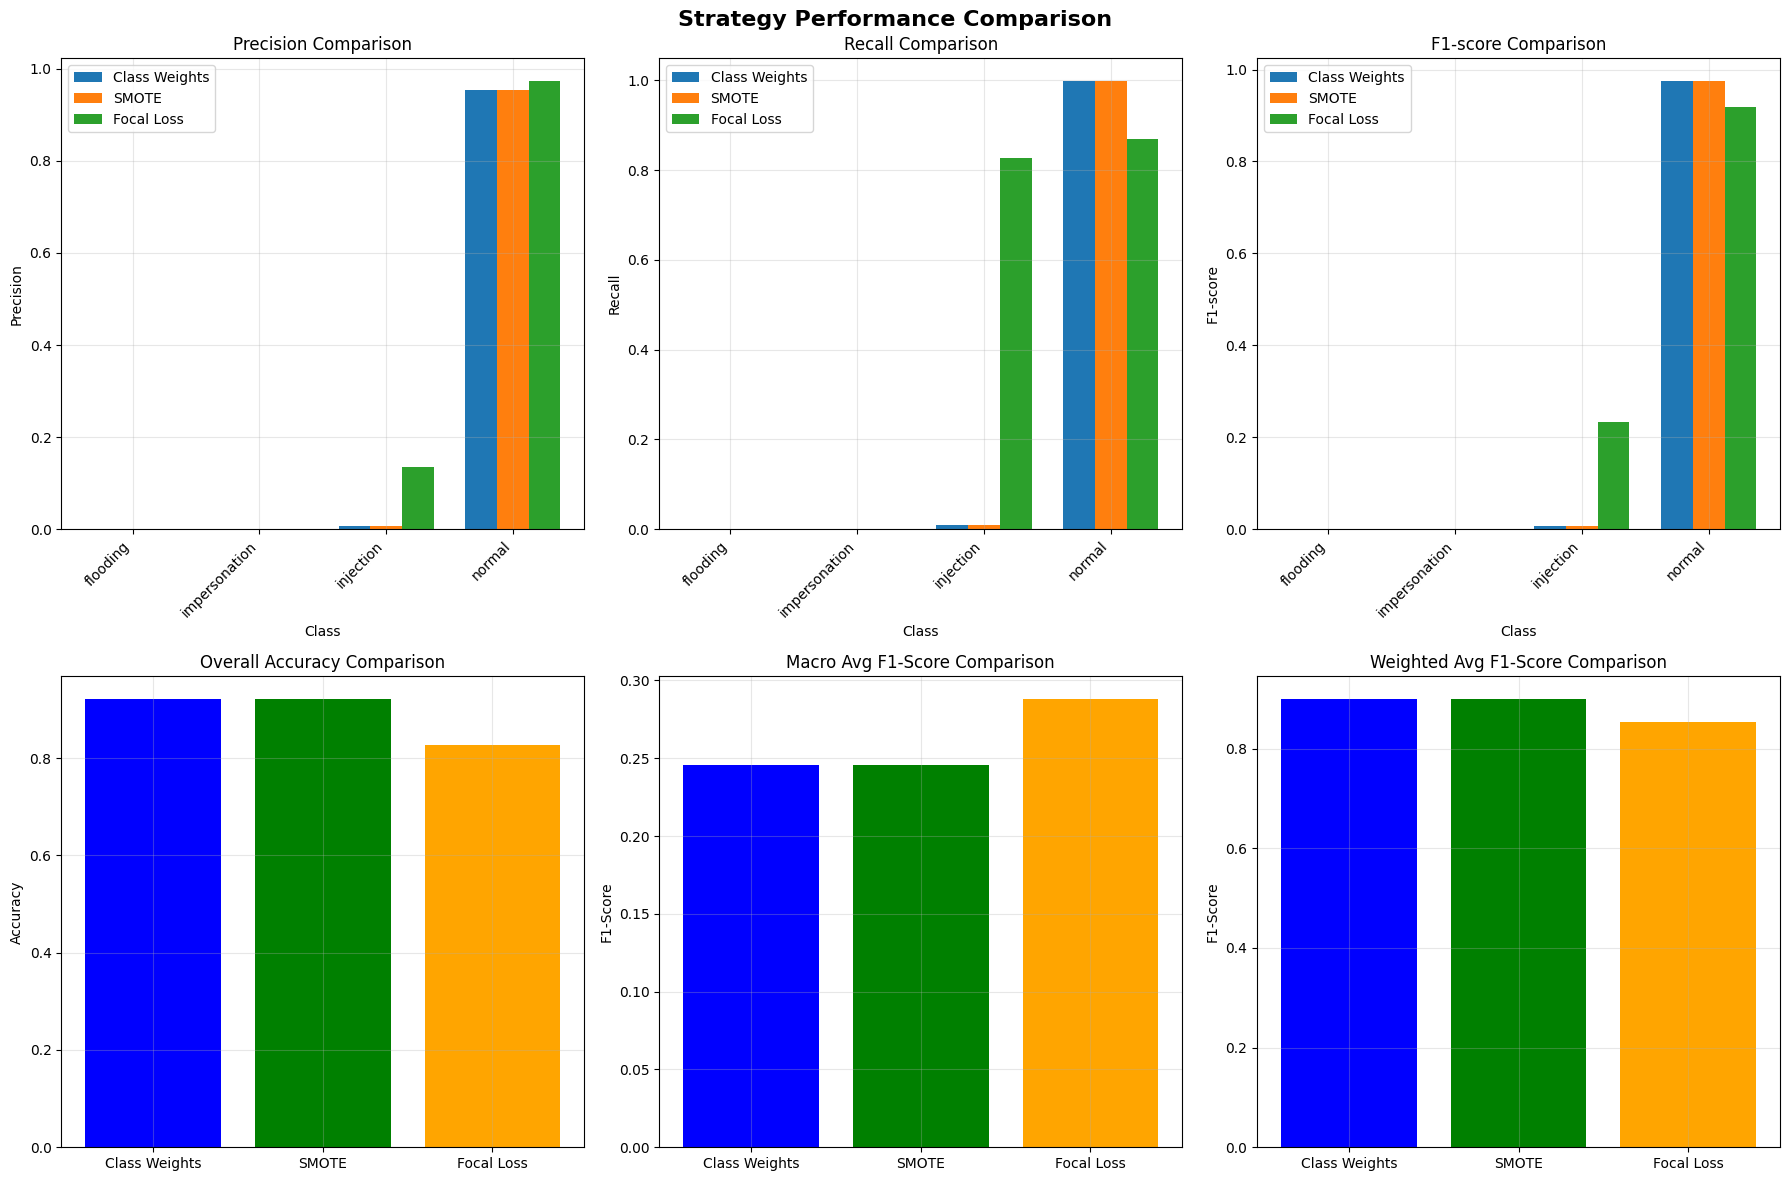


🏆 Best Strategy: Focal Loss


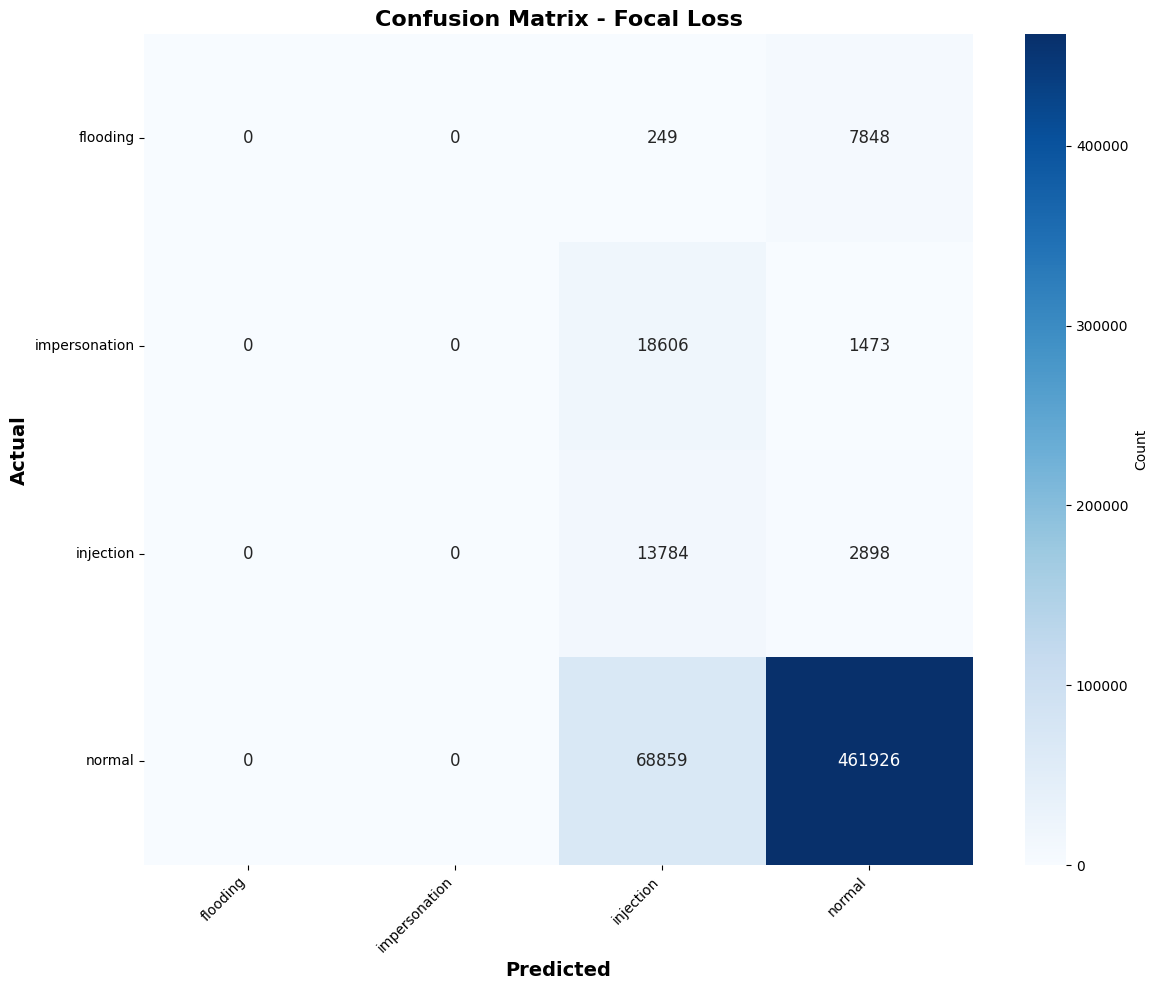


📊 Detailed Metrics for Focal Loss:
--------------------------------------------------

flooding       :
  TP:      0 | FP:      0 | FN:   8097 | TN: 567546
  Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000

impersonation  :
  TP:      0 | FP:      0 | FN:  20079 | TN: 555564
  Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000

injection      :
  TP:  13784 | FP:  87714 | FN:   2898 | TN: 471247
  Precision: 0.1358 | Recall: 0.8263 | F1: 0.2333

normal         :
  TP: 461926 | FP:  12219 | FN:  68859 | TN:  32639
  Precision: 0.9742 | Recall: 0.8703 | F1: 0.9193

FINAL SUMMARY - ALL STRATEGIES

📈 Class Weights:
  Accuracy:  0.9217
  Macro Avg Precision: 0.2401
  Macro Avg Recall:    0.2519
  Macro Avg F1-Score:  0.2459
  Weighted Avg F1:     0.8999

📈 SMOTE:
  Accuracy:  0.9217
  Macro Avg Precision: 0.2401
  Macro Avg Recall:    0.2519
  Macro Avg F1-Score:  0.2459
  Weighted Avg F1:     0.8999

📈 Focal Loss:
  Accuracy:  0.8264
  Macro Avg Precision: 0.2775
  Macro Avg Recall:    0.424

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
print("="*60)
print("ENHANCED CNN INTRUSION DETECTION SYSTEM")
print("="*60)

# --- PHASE 1: DATA LOADING ---
train_path = '/kaggle/input/awidclsr/AWID-CLS-R-Trn/AWID-CLS-R-Trn/1'
test_path = '/kaggle/input/awidclsr/AWID-CLS-R-Tst/AWID-CLS-R-Tst/1'

# 13 pivotal features + class label based on the paper's feature selection [cite: 21]
pivotal_indices = [7, 13, 14, 15, 125, 126, 128, 139, 140, 63, 68, 37, 38, 154]

print("\n📊 Loading Dataset...")
df_train = pd.read_csv(train_path, header=None, usecols=pivotal_indices, low_memory=False)
df_test = pd.read_csv(test_path, header=None, usecols=pivotal_indices, low_memory=False)

cols = ['frame_len', 'rtap_len', 'rtap_tsft', 'rtap_flags', 'rtap_rate',
        'rtap_freq', 'rtap_type_cck', 'rtap_sig', 'rtap_ant', 'wlan_type',
        'wlan_ds', 'wlan_ra', 'wlan_da', 'label']
df_train.columns = cols
df_test.columns = cols

print(f"Training samples: {len(df_train):,}")
print(f"Testing samples: {len(df_test):,}")

# --- PHASE 2: PREPROCESSING & SCALING ---
def preprocess_for_cnn(df):
    features = df.drop('label', axis=1).copy()
    label = df['label'].copy()

    # Replace errors and nulls as per methodology [cite: 247-250]
    features.replace('?', np.nan, inplace=True)
    features.fillna('0', inplace=True)

    # Convert Hexadecimal to Integer [cite: 251-252]
    hex_cols = ['wlan_type', 'wlan_ds', 'wlan_ra', 'wlan_da', 'rtap_flags', 'rtap_tsft']
    for col in hex_cols:
        features[col] = features[col].apply(lambda x: int(str(x), 16) if 'x' in str(x) else x)
        features[col] = features[col].apply(lambda x: int(str(x).replace(':', ''), 16) if ':' in str(x) else x)

    features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
    return features, label

print("\n🧹 Cleaning data and applying Standard Scaling...")
X_train_raw, y_train_raw = preprocess_for_cnn(df_train)
X_test_raw, y_test_raw = preprocess_for_cnn(df_test)

# Standard Scaling ensures features have equal weight for the CNN [cite: 253-255]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Label Encoding [cite: 256-258]
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw.astype(str))
y_test = le.transform(y_test_raw.astype(str))
target_names = [str(c) for c in le.classes_]

print(f"\nClass Distribution in Training Set:")
for i, name in enumerate(target_names):
    count = np.sum(y_train == i)
    percentage = count / len(y_train) * 100
    print(f"  {name:15s}: {count:8,d} ({percentage:.2f}%)")

# ============================================================================
# PHASE 3: HANDLING CLASS IMBALANCE - MULTIPLE STRATEGIES
# ============================================================================

print("\n" + "="*60)
print("STRATEGY 1: CLASS WEIGHTS (Current Approach)")
print("="*60)

# Calculate weights to fix the "0% accuracy on attacks" issue
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print(f"Class Weights:")
for i, name in enumerate(target_names):
    print(f"  {name:15s}: {weights[i]:.2f}")

# ============================================================================
# STRATEGY 2: SMOTE OVERSAMPLING
# ============================================================================

print("\n" + "="*60)
print("STRATEGY 2: SMOTE Oversampling")
print("="*60)

try:
    # Apply SMOTE to balance the dataset
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print(f"After SMOTE - Class Distribution:")
    unique, counts = np.unique(y_train_smote, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"  {target_names[cls]:15s}: {count:8,d}")

    # Reshape for CNN
    X_train_smote = X_train_smote.reshape(X_train_smote.shape[0], 13, 1)

except Exception as e:
    print(f"SMOTE failed: {e}")
    X_train_smote = None

# ============================================================================
# STRATEGY 3: FOCAL LOSS FUNCTION
# ============================================================================

print("\n" + "="*60)
print("STRATEGY 3: Focal Loss Implementation")
print("="*60)

def focal_loss(gamma=2., alpha=0.25):
    """
    Focal loss for multi-class classification
    Focuses on hard-to-classify examples
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Convert to one-hot
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(target_names))

        # Calculate cross entropy
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)

        # Calculate focal weight
        weight = tf.pow(1 - y_pred, gamma) * y_true_one_hot

        # Apply alpha balancing
        alpha_tensor = tf.ones_like(y_pred) * alpha
        alpha_weight = y_true_one_hot * alpha_tensor + (1 - y_true_one_hot) * (1 - alpha_tensor)

        # Combine
        focal_loss_value = alpha_weight * weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss_value, axis=1))

    return focal_loss_fixed

# ============================================================================
# PHASE 4: ENHANCED CNN ARCHITECTURE
# ============================================================================

def create_enhanced_cnn(input_shape=(13, 1), num_classes=4):
    """
    Create enhanced CNN with better feature extraction for minority classes
    """
    inputs = Input(shape=input_shape)

    # Block 1: Feature extraction
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2: Deeper features
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3: Attention mechanism for important features
    x = layers.Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Squeeze-and-Excitation block (channel attention)
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(128, activation='relu')(se)
    se = layers.Dense(256, activation='sigmoid')(se)
    se = layers.Reshape((1, 256))(se)
    x = layers.multiply([x, se])

    # Global pooling
    x = layers.GlobalMaxPooling1D()(x)

    # Dense layers for classification
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# ============================================================================
# PHASE 5: TRAINING WITH DIFFERENT STRATEGIES
# ============================================================================

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       class_weight=None, use_focal=False, strategy_name=""):
    """
    Train and evaluate model with given strategy
    """
    print(f"\n📈 Training with {strategy_name}...")

    # Callbacks
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
        callbacks.ModelCheckpoint(f'best_model_{strategy_name}.h5', save_best_only=True)
    ]

    # Compile with appropriate loss
    if use_focal:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss=focal_loss(gamma=2.0, alpha=0.25),
                     metrics=['accuracy'])
    else:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=1024,
        validation_split=0.2,
        class_weight=class_weight,
        callbacks=callbacks_list,
        verbose=0
    )

    # Evaluate
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Calculate per-class metrics
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

    return model, history, y_pred, report

# ============================================================================
# PHASE 6: RUN ALL STRATEGIES AND COMPARE
# ============================================================================

# Prepare data for CNN
X_train_original = X_train_scaled.reshape(X_train_scaled.shape[0], 13, 1)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], 13, 1)

results = {}
strategies = []

# Strategy 1: Original with class weights
print("\n" + "="*60)
print("STRATEGY 1: Class Weights")
print("="*60)
model1 = create_enhanced_cnn(num_classes=len(target_names))
model1, hist1, pred1, report1 = train_and_evaluate(
    model1, X_train_original, y_train, X_test, y_test,
    class_weight=class_weight_dict, use_focal=False,
    strategy_name="class_weights"
)
results['Class Weights'] = report1
strategies.append('Class Weights')

# Strategy 2: SMOTE if available
if X_train_smote is not None:
    print("\n" + "="*60)
    print("STRATEGY 2: SMOTE + Class Weights")
    print("="*60)
    model2 = create_enhanced_cnn(num_classes=len(target_names))
    model2, hist2, pred2, report2 = train_and_evaluate(
        model2, X_train_smote, y_train_smote, X_test, y_test,
        class_weight=None, use_focal=False,
        strategy_name="smote"
    )
    results['SMOTE'] = report2
    strategies.append('SMOTE')

# Strategy 3: Focal Loss
print("\n" + "="*60)
print("STRATEGY 3: Focal Loss")
print("="*60)
model3 = create_enhanced_cnn(num_classes=len(target_names))
model3, hist3, pred3, report3 = train_and_evaluate(
    model3, X_train_original, y_train, X_test, y_test,
    class_weight=None, use_focal=True,
    strategy_name="focal_loss"
)
results['Focal Loss'] = report3
strategies.append('Focal Loss')

# ============================================================================
# PHASE 7: VISUALIZATION AND COMPARISON
# ============================================================================

def plot_strategy_comparison(results, strategies, target_names, save_path='.'):
    """
    Plot comparison of different strategies
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    metrics = ['precision', 'recall', 'f1-score']

    for idx, metric in enumerate(metrics):
        ax = axes[0, idx]

        x = np.arange(len(target_names))
        width = 0.25

        for i, strategy in enumerate(strategies):
            values = [results[strategy][cls][metric] for cls in target_names]
            ax.bar(x + i*width, values, width, label=strategy)

        ax.set_xlabel('Class')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{metric.capitalize()} Comparison')
        ax.set_xticks(x + width)
        ax.set_xticklabels(target_names, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Accuracy comparison
    ax = axes[1, 0]
    accuracies = [results[strategy]['accuracy'] for strategy in strategies]
    ax.bar(strategies, accuracies, color=['blue', 'green', 'orange'])
    ax.set_title('Overall Accuracy Comparison')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)

    # Macro avg comparison
    ax = axes[1, 1]
    macro_f1 = [results[strategy]['macro avg']['f1-score'] for strategy in strategies]
    ax.bar(strategies, macro_f1, color=['blue', 'green', 'orange'])
    ax.set_title('Macro Avg F1-Score Comparison')
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3)

    # Weighted avg comparison
    ax = axes[1, 2]
    weighted_f1 = [results[strategy]['weighted avg']['f1-score'] for strategy in strategies]
    ax.bar(strategies, weighted_f1, color=['blue', 'green', 'orange'])
    ax.set_title('Weighted Avg F1-Score Comparison')
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Strategy Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'strategy_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Plot comparison
plot_strategy_comparison(results, strategies, target_names, '.')

# ============================================================================
# PHASE 8: DETAILED CONFUSION MATRIX FOR BEST STRATEGY
# ============================================================================

def plot_confusion_matrix_with_counts(y_true, y_pred, target_names, strategy_name, save_path='.'):
    """
    Plot confusion matrix with actual counts
    """
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Create heatmap
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                ax=ax,
                cbar_kws={'label': 'Count'},
                annot_kws={'size': 12})

    ax.set_xlabel('Predicted', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=14, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {strategy_name}', fontsize=16, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'confusion_matrix_{strategy_name}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print per-class metrics
    print(f"\n📊 Detailed Metrics for {strategy_name}:")
    print("-" * 50)
    for i, class_name in enumerate(target_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        print(f"\n{class_name:15s}:")
        print(f"  TP: {tp:6d} | FP: {fp:6d} | FN: {fn:6d} | TN: {tn:6d}")
        print(f"  Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Get best strategy (based on macro F1)
best_strategy = strategies[np.argmax([results[s]['macro avg']['f1-score'] for s in strategies])]
print(f"\n🏆 Best Strategy: {best_strategy}")

# Plot confusion matrix for best strategy
if best_strategy == 'Class Weights':
    plot_confusion_matrix_with_counts(y_test, pred1, target_names, best_strategy)
elif best_strategy == 'SMOTE' and X_train_smote is not None:
    plot_confusion_matrix_with_counts(y_test, pred2, target_names, best_strategy)
else:
    plot_confusion_matrix_with_counts(y_test, pred3, target_names, best_strategy)

# ============================================================================
# PHASE 9: FINAL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("FINAL SUMMARY - ALL STRATEGIES")
print("="*60)

for strategy in strategies:
    print(f"\n📈 {strategy}:")
    print(f"  Accuracy:  {results[strategy]['accuracy']:.4f}")
    print(f"  Macro Avg Precision: {results[strategy]['macro avg']['precision']:.4f}")
    print(f"  Macro Avg Recall:    {results[strategy]['macro avg']['recall']:.4f}")
    print(f"  Macro Avg F1-Score:  {results[strategy]['macro avg']['f1-score']:.4f}")
    print(f"  Weighted Avg F1:     {results[strategy]['weighted avg']['f1-score']:.4f}")

print("\n" + "="*60)
print("RECOMMENDATIONS:")
print("="*60)
print("""
To further improve detection of minority classes:

1. COLLECT MORE DATA: Gather more samples of flooding, impersonation, and injection attacks
2. ENSEMBLE METHODS: Combine multiple models trained on different balanced subsets
3. COST-SENSITIVE LEARNING: Assign higher misclassification costs to minority classes
4. DATA AUGMENTATION: Generate synthetic attack samples using GANs
5. THRESHOLD TUNING: Adjust decision thresholds per class
6. FEATURE ENGINEERING: Create more discriminative features for attacks
""")

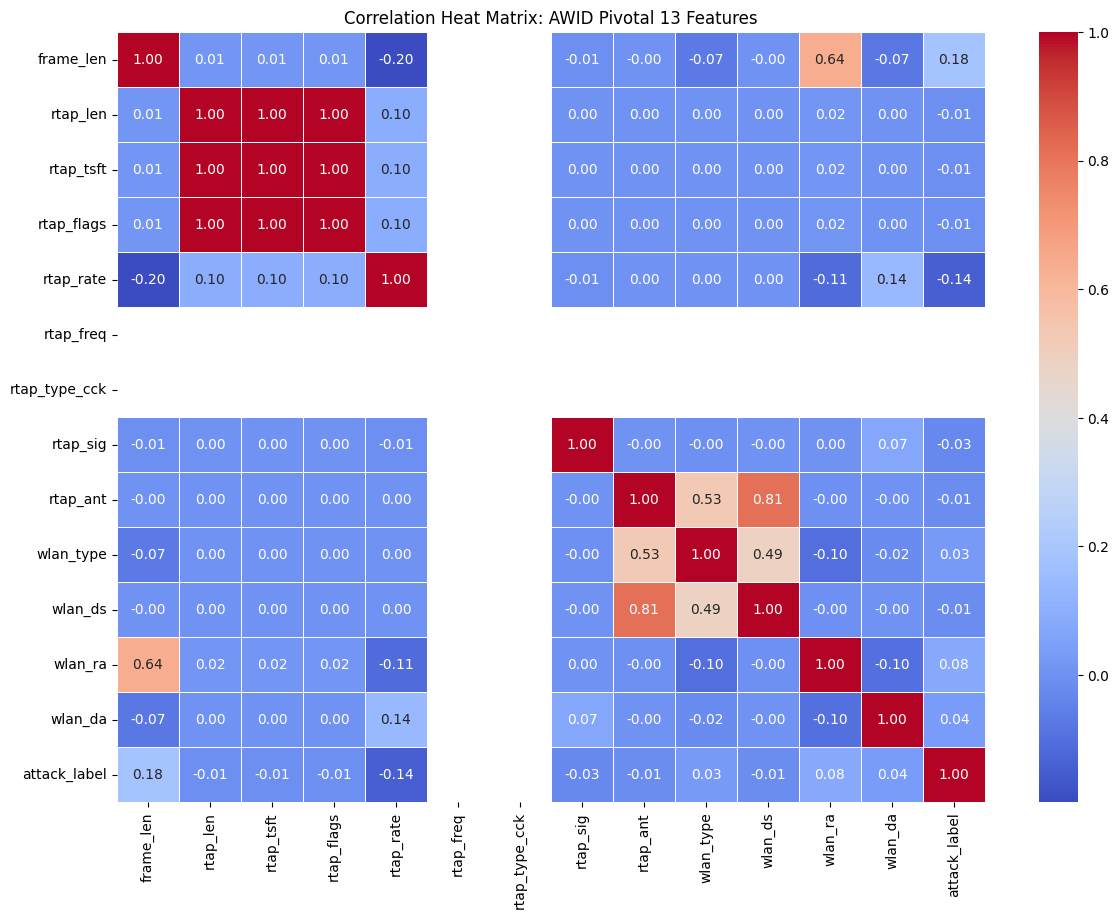

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine features and labels for the correlation check
# We use the label-encoded 'y_train' to see how features relate to the attack types
correlation_df = X_train_raw.copy()
correlation_df['attack_label'] = y_train

# 2. Compute the correlation matrix
# Correlation values range from -1 (inverse) to +1 (direct)
corr = correlation_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heat Matrix: AWID Pivotal 13 Features')
plt.show()


Generating Confusion Matrix...


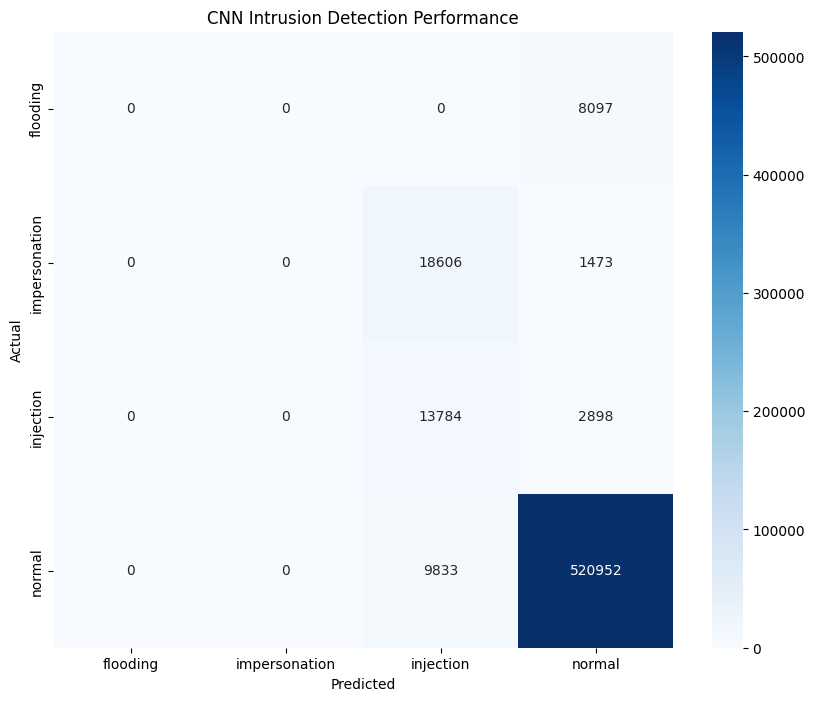

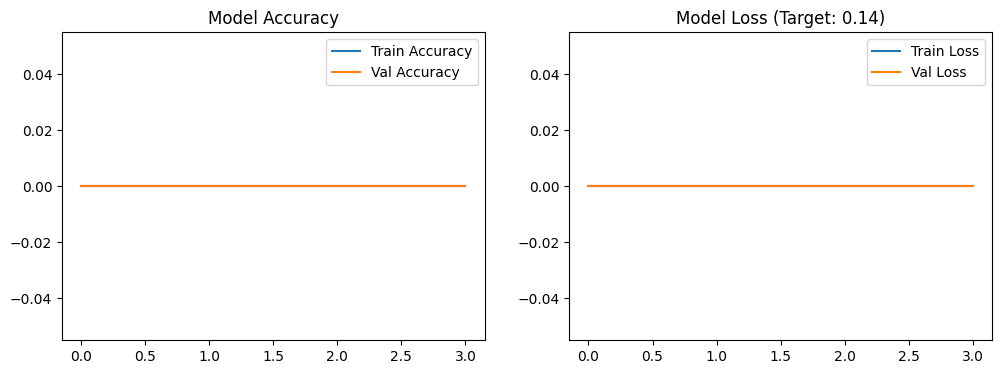

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Intrusion Detection Performance')
plt.show()

# 2. Plot Training History (Accuracy and Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Target: 0.14)')
plt.legend()
plt.show()

## 📦 Cell 1: Mount Google Drive

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# -------------------------------------------------------
# ✏️ CHANGE THIS if your folder name is different
DRIVE_FOLDER = '/content/drive/MyDrive/AWID'
# -------------------------------------------------------

TRAIN_PATH = os.path.join(DRIVE_FOLDER, 'AWID-CLS-R-Trn.csv')
TEST_PATH  = os.path.join(DRIVE_FOLDER, 'AWID-CLS-R-Tst.csv')

# Check files exist
train_exists = os.path.exists(TRAIN_PATH)
test_exists  = os.path.exists(TEST_PATH)

print('='*55)
print('📂 Google Drive mounted!')
print('='*55)
print(f'Training file found : {"✅ YES" if train_exists else "❌ NOT FOUND"}')
print(f'Testing  file found : {"✅ YES" if test_exists  else "❌ NOT FOUND"}')
print('='*55)

if not train_exists or not test_exists:
    print()
    print('⚠️  FILES NOT FOUND! Please check:')
    print(f'   Expected location: {DRIVE_FOLDER}')
    print('   1. Make sure you uploaded both CSV files to Google Drive')
    print('   2. Create a folder called AWID in My Drive')
    print('   3. Place both CSV files inside that folder')
    print('   4. Re-run this cell')
else:
    print()
    print('🚀 Files found! You can proceed to the next cell.')

Mounted at /content/drive
📂 Google Drive mounted!
Training file found : ❌ NOT FOUND
Testing  file found : ❌ NOT FOUND

⚠️  FILES NOT FOUND! Please check:
   Expected location: /content/drive/MyDrive/AWID
   1. Make sure you uploaded both CSV files to Google Drive
   2. Create a folder called AWID in My Drive
   3. Place both CSV files inside that folder
   4. Re-run this cell


## 📦 Cell 2: Install & Import Libraries

In [ ]:
# Install extra libraries not in Colab by default
!pip install xgboost lightgbm shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.linear_model import LogisticRegression

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D,
                                      Flatten, LSTM, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Improvement libraries
import xgboost as xgb
import lightgbm as lgb
import shap

print('='*55)
print('✅ All libraries imported!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   XGBoost    : {xgb.__version__}')
print(f'   GPU found  : {"Yes ✅" if len(tf.config.list_physical_devices("GPU")) > 0 else "No (CPU only)"}')
print('='*55)

✅ All libraries imported!
   TensorFlow : 2.19.0
   XGBoost    : 3.2.0
   GPU found  : Yes ✅


## 📦 Cell 3: Load Dataset from Drive

In [ ]:
# Column names: 154 features + 1 class label
col_names = [f'f{i}' for i in range(1, 155)] + ['class']

print('📂 Loading training data from Google Drive...')
print('   (This may take 1-2 minutes for large files)')
train_df = pd.read_csv(TRAIN_PATH, header=None, names=col_names, low_memory=False)
print(f'   ✅ Training loaded: {train_df.shape}')

print('📂 Loading testing data from Google Drive...')
test_df = pd.read_csv(TEST_PATH, header=None, names=col_names, low_memory=False)
print(f'   ✅ Testing loaded:  {test_df.shape}')

print()
print('📊 Class Distribution (Training):')
print(train_df['class'].value_counts().to_string())
print()
print('📊 Class Distribution (Testing):')
print(test_df['class'].value_counts().to_string())

# Quick pie chart of class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['class'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_ylabel('')
test_df['class'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Testing Set - Class Distribution')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AWID/class_distribution.png', dpi=150)
plt.show()
print('✅ Chart saved to Google Drive!')

📂 Loading training data from Google Drive...
   (This may take 1-2 minutes for large files)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AWID/AWID-CLS-R-Trn.csv'

## 📦 Cell 4: Data Preprocessing

In [ ]:
print('🔧 Preprocessing data...')
print('-'*45)

# Step 1: Replace '?' with NaN
train_df.replace('?', np.nan, inplace=True)
test_df.replace('?', np.nan, inplace=True)
print('✅ Step 1: Replaced ? with NaN')

# Step 2: Drop columns with >50% null values
threshold = 0.5 * len(train_df)
cols_before = train_df.shape[1]
train_df.dropna(axis=1, thresh=int(threshold), inplace=True)
test_df = test_df[train_df.columns]
cols_after = train_df.shape[1]
print(f'✅ Step 2: Dropped {cols_before - cols_after} columns with >50% nulls')

# Step 3: Drop null rows
rows_before = len(train_df)
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
print(f'✅ Step 3: Dropped {rows_before - len(train_df)} null rows')

# Step 4: Convert to numeric
feature_cols = [c for c in train_df.columns if c != 'class']
for col in feature_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce').fillna(0)
    test_df[col]  = pd.to_numeric(test_df[col],  errors='coerce').fillna(0)
print(f'✅ Step 4: Converted all features to numeric')

print('-'*45)
print(f'📐 Final Train shape : {train_df.shape}')
print(f'📐 Final Test  shape : {test_df.shape}')
print(f'🔢 Total features    : {len(feature_cols)}')

## 📦 Cell 5: Feature Selection (154 → 76 → 13)

In [ ]:
# --- Select top 76 features by variance ---
print('🔍 Selecting top 76 features by variance...')
X_all = train_df[feature_cols]
variances = X_all.var()
features_76 = variances.nlargest(76).index.tolist()
print(f'✅ 76 features selected')

# --- Select top 13 features by correlation with class ---
print('🔍 Selecting top 13 features by class correlation...')
le_temp = LabelEncoder()
y_encoded = le_temp.fit_transform(train_df['class'].str.strip().str.lower())
X_76 = train_df[features_76]
correlations = X_76.apply(lambda col: abs(np.corrcoef(col, y_encoded)[0, 1]))
features_13 = correlations.nlargest(13).index.tolist()
print(f'✅ 13 features selected: {features_13}')

# Plot top 13 feature importances
plt.figure(figsize=(10, 5))
top_corr = correlations.nlargest(20)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.axvline(x=correlations[features_13[-1]], color='red',
            linestyle='--', label='13-feature cutoff')
plt.title('Top 20 Features by Correlation with Class Label')
plt.xlabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AWID/feature_importance.png', dpi=150)
plt.show()
print('✅ Feature importance chart saved to Google Drive!')

## 📦 Cell 6: Prepare Arrays for Training

In [ ]:
def prepare_arrays(train_df, test_df, feature_cols, binary=True):
    le = LabelEncoder()

    X_train = train_df[feature_cols].values
    X_test  = test_df[feature_cols].values

    if binary:
        y_tr = train_df['class'].apply(
            lambda x: 'normal' if str(x).strip().lower() == 'normal' else 'attack')
        y_te = test_df['class'].apply(
            lambda x: 'normal' if str(x).strip().lower() == 'normal' else 'attack')
    else:
        y_tr = train_df['class'].str.strip().str.lower()
        y_te = test_df['class'].str.strip().str.lower()

    y_train = le.fit_transform(y_tr)
    y_test  = le.transform(y_te)
    n_cls   = len(le.classes_)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    y_tr_cat = to_categorical(y_train, n_cls)
    y_te_cat = to_categorical(y_test,  n_cls)

    # 3D reshape for CNN / LSTM
    X_tr3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_te3d = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

    print(f'✅ Classes : {le.classes_}')
    print(f'   X_train : {X_train.shape}  |  y_train: {y_train.shape}')
    print(f'   X_test  : {X_test.shape}   |  y_test : {y_test.shape}')

    return X_train, X_test, X_tr3d, X_te3d, y_train, y_test, y_tr_cat, y_te_cat, n_cls, le, scaler

print('⚙️  Preparing arrays for Binary Classification (76 features)...')
print('-'*55)
(X_tr, X_te, X_tr3d, X_te3d,
 y_tr, y_te, y_tr_cat, y_te_cat,
 n_cls, le, scaler) = prepare_arrays(train_df, test_df, features_76, binary=True)

class_names = list(le.classes_)
print(f'\n✅ Ready to train! Number of classes: {n_cls}')

## 📦 Cell 7: Define All Models

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=0)

def train_model(model, name, X_tr, y_tr_cat, X_te, y_te_cat,
                epochs=30, batch_size=512):
    print(f'\n🏋️ Training {name}...')
    history = model.fit(X_tr, y_tr_cat, validation_split=0.1,
                        epochs=epochs, batch_size=batch_size,
                        callbacks=[early_stop], verbose=0)
    loss, acc = model.evaluate(X_te, y_te_cat, verbose=0)
    print(f'   ✅ Loss: {loss:.4f}  |  Accuracy: {acc:.4f}')
    return model, history, loss, acc

# ---- DNN 5 layers ----
def build_dnn5(d, c):
    m = Sequential([
        Input(shape=(d,)),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(64,  activation='relu'), Dropout(0.3),
        Dense(32,  activation='relu'), Dropout(0.2),
        Dense(c,   activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# ---- DNN 3 layers ----
def build_dnn3(d, c):
    m = Sequential([
        Input(shape=(d,)),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(64,  activation='relu'), Dropout(0.3),
        Dense(c,   activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# ---- CNN (paper's main model - 97%) ----
def build_cnn(d, c):
    m = Sequential([
        Input(shape=(d, 1)),
        Conv1D(32, 3, activation='relu', padding='same'),
        MaxPooling1D(2), Dropout(0.3),
        Conv1D(64, 3, activation='relu', padding='same'),
        MaxPooling1D(2), Dropout(0.3),
        Flatten(),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(c, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# ---- RNN-LSTM ----
def build_lstm(d, c):
    m = Sequential([
        Input(shape=(d, 1)),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(64, activation='relu'), Dropout(0.2),
        Dense(c, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

# ---- Transformer (🚀 YOUR IMPROVEMENT) ----
def build_transformer(d, c):
    inputs = keras.Input(shape=(d, 1))
    x = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Dropout(0.2)(x)
    x = Conv1D(64, 1, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(c, activation='softmax')(x)
    m = keras.Model(inputs, out)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

print('✅ All model definitions ready!')
print()
print('Models to be trained:')
print('  📄 Paper models  : DNN(5), DNN(3), CNN, RNN-LSTM, Logistic Regression')
print('  🚀 Improvements  : Transformer, XGBoost, LightGBM')

## 📦 Cell 8: Train Paper Models (DNN5, DNN3, CNN, LSTM)

In [ ]:
results = {}  # store all model accuracies

# DNN(5)
dnn5, h_dnn5, l_dnn5, a_dnn5 = train_model(
    build_dnn5(X_tr.shape[1], n_cls), 'DNN(5)',
    X_tr, y_tr_cat, X_te, y_te_cat)
results['Paper: DNN(5)'] = a_dnn5

# DNN(3)
dnn3, h_dnn3, l_dnn3, a_dnn3 = train_model(
    build_dnn3(X_tr.shape[1], n_cls), 'DNN(3)',
    X_tr, y_tr_cat, X_te, y_te_cat)
results['Paper: DNN(3)'] = a_dnn3

# CNN
cnn, h_cnn, l_cnn, a_cnn = train_model(
    build_cnn(X_tr3d.shape[1], n_cls), 'CNN',
    X_tr3d, y_tr_cat, X_te3d, y_te_cat)
results['Paper: CNN'] = a_cnn

# LSTM
lstm, h_lstm, l_lstm, a_lstm = train_model(
    build_lstm(X_tr3d.shape[1], n_cls), 'RNN-LSTM',
    X_tr3d, y_tr_cat, X_te3d, y_te_cat)
results['Paper: LSTM'] = a_lstm

# Logistic Regression
print('\n🏋️ Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr, y_tr)
results['Paper: LR'] = lr.score(X_te, y_te)
print(f'   ✅ Accuracy: {results["Paper: LR"]:.4f}')

print('\n' + '='*45)
print('✅ All paper models trained!')
print('='*45)

## 📦 Cell 9: Train Improvement Models (Transformer, XGBoost, LightGBM)

In [ ]:
# Transformer
transformer, h_tf, l_tf, a_tf = train_model(
    build_transformer(X_tr3d.shape[1], n_cls), 'Transformer',
    X_tr3d, y_tr_cat, X_te3d, y_te_cat)
results['Improved: Transformer'] = a_tf

# XGBoost
print('\n🏋️ Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss', random_state=42
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
results['Improved: XGBoost'] = xgb_model.score(X_te, y_te)
print(f'   ✅ Accuracy: {results["Improved: XGBoost"]:.4f}')

# LightGBM
print('\n🏋️ Training LightGBM...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=42, verbose=-1
)
lgb_model.fit(X_tr, y_tr)
results['Improved: LightGBM'] = lgb_model.score(X_te, y_te)
print(f'   ✅ Accuracy: {results["Improved: LightGBM"]:.4f}')

print('\n' + '='*45)
print('✅ All improvement models trained!')
print('='*45)

## 📦 Cell 10: Averaging Ensemble

In [ ]:
print('🔗 Running Averaging Ensemble (CNN + LSTM + Transformer)...')

probs_cnn  = cnn.predict(X_te3d, verbose=0)
probs_lstm = lstm.predict(X_te3d, verbose=0)
probs_tf   = transformer.predict(X_te3d, verbose=0)

avg_probs = (probs_cnn + probs_lstm + probs_tf) / 3
y_pred_ens = np.argmax(avg_probs, axis=1)
acc_ens = accuracy_score(y_te, y_pred_ens)

results['Improved: Ensemble'] = acc_ens
print(f'✅ Ensemble Accuracy: {acc_ens:.4f}')

## 📦 Cell 11: Evaluation - Confusion Matrices & Reports

In [ ]:
def evaluate_and_plot(name, y_true, y_pred, class_names, save_path):
    print(f'\n{"="*55}')
    print(f'📊 {name}')
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

SAVE_DIR = '/content/drive/MyDrive/AWID/'

# CNN (paper's best model)
y_pred_cnn = np.argmax(cnn.predict(X_te3d, verbose=0), axis=1)
evaluate_and_plot('CNN (Paper Model)', y_te, y_pred_cnn,
                  class_names, SAVE_DIR + 'cm_cnn.png')

# Transformer (improvement)
y_pred_tf = np.argmax(transformer.predict(X_te3d, verbose=0), axis=1)
evaluate_and_plot('Transformer (Improvement)', y_te, y_pred_tf,
                  class_names, SAVE_DIR + 'cm_transformer.png')

# XGBoost
y_pred_xgb = xgb_model.predict(X_te)
evaluate_and_plot('XGBoost (Improvement)', y_te, y_pred_xgb,
                  class_names, SAVE_DIR + 'cm_xgboost.png')

print('\n✅ All confusion matrices saved to Google Drive!')

## 📦 Cell 12: Training History Plots

In [ ]:
def plot_history(history, name, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.suptitle(name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(h_cnn,  'CNN',         SAVE_DIR + 'history_cnn.png')
plot_history(h_lstm, 'RNN-LSTM',    SAVE_DIR + 'history_lstm.png')
plot_history(h_tf,   'Transformer', SAVE_DIR + 'history_transformer.png')

print('✅ Training history plots saved to Google Drive!')

## 📦 Cell 13: Detection Rate & False Alarm Rate

In [ ]:
def dr_far(y_true, y_pred, attack_idx):
    tp = np.sum((y_pred == attack_idx) & (y_true == attack_idx))
    fn = np.sum((y_pred != attack_idx) & (y_true == attack_idx))
    fp = np.sum((y_pred == attack_idx) & (y_true != attack_idx))
    tn = np.sum((y_pred != attack_idx) & (y_true != attack_idx))
    dr  = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return dr, far, int(tp), int(fp)

attack_idx = list(le.classes_).index('attack') if 'attack' in le.classes_ else 0

print('📡 Detection Rate (DR) & False Alarm Rate (FAR)')
print('='*55)

model_preds = {
    'CNN'        : y_pred_cnn,
    'Transformer': y_pred_tf,
    'XGBoost'    : y_pred_xgb,
    'Ensemble'   : y_pred_ens
}

dr_far_results = {}
for name, preds in model_preds.items():
    dr, far, tp, fp = dr_far(y_te, preds, attack_idx)
    dr_far_results[name] = (dr, far)
    print(f'{name:15s} → DR: {dr:.4f}  |  FAR: {far:.4f}  |  TP: {tp}  |  FP: {fp}')

# Plot DR vs FAR
fig, ax = plt.subplots(figsize=(8, 5))
names = list(dr_far_results.keys())
drs   = [v[0] for v in dr_far_results.values()]
fars  = [v[1] for v in dr_far_results.values()]
x = np.arange(len(names))
bars1 = ax.bar(x - 0.2, drs,  0.35, label='Detection Rate',   color='#4CAF50')
bars2 = ax.bar(x + 0.2, fars, 0.35, label='False Alarm Rate', color='#F44336')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_title('Detection Rate vs False Alarm Rate')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + 'dr_far_comparison.png', dpi=150)
plt.show()
print('✅ DR/FAR chart saved to Google Drive!')

## 📦 Cell 14: SHAP Feature Importance (XGBoost)

In [ ]:
print('🔍 Computing SHAP values (using 1000 samples for speed)...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_tr[:1000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_tr[:1000],
                  feature_names=features_76,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance - XGBoost')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'shap_importance.png', dpi=150)
plt.show()
print('✅ SHAP chart saved to Google Drive!')

## 📦 Cell 15: Final Results Summary & Comparison Chart

In [ ]:
print('\n' + '='*60)
print('🏆 FINAL RESULTS SUMMARY')
print('='*60)

best_acc = max(results.values())
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    trophy = '🏆' if acc == best_acc else '  '
    beat   = '✅ BEATS PAPER!' if acc > 0.97 else ''
    print(f'{trophy} {name:35s}: {acc*100:.2f}%  {beat}')

print(f'\n📌 Paper CNN baseline: 97.00%')
print('='*60)

# Bar chart comparison
names = list(results.keys())
accs  = [v * 100 for v in results.values()]
colors = ['#2196F3' if 'Paper' in n else '#4CAF50' for n in names]

plt.figure(figsize=(13, 6))
bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.2)
plt.axhline(y=97, color='red', linestyle='--', linewidth=2,
            label='Paper CNN Baseline (97%)')
plt.ylim(80, 102)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Comparison - IDS for WSN (AWID Dataset)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.legend(fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Paper Models'),
    Patch(facecolor='#4CAF50', label='Improved Models'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='97% Baseline')
]
plt.legend(handles=legend_elements, fontsize=10)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'final_model_comparison.png', dpi=150)
plt.show()

print('\n✅ Final comparison chart saved to Google Drive!')
print('\n📁 All output files saved in: My Drive/AWID/')
print('   - class_distribution.png')
print('   - feature_importance.png')
print('   - cm_cnn.png')
print('   - cm_transformer.png')
print('   - cm_xgboost.png')
print('   - history_cnn.png')
print('   - history_lstm.png')
print('   - history_transformer.png')
print('   - dr_far_comparison.png')
print('   - shap_importance.png')
print('   - final_model_comparison.png')

## 📦 Cell 16: Save Models to Google Drive

In [ ]:
import pickle

# Save Keras models
cnn.save(SAVE_DIR + 'model_cnn.h5')
lstm.save(SAVE_DIR + 'model_lstm.h5')
transformer.save(SAVE_DIR + 'model_transformer.h5')
print('✅ Deep learning models saved!')

# Save sklearn / xgboost models
with open(SAVE_DIR + 'model_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open(SAVE_DIR + 'model_lgb.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
with open(SAVE_DIR + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(SAVE_DIR + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✅ ML models + scaler + label encoder saved!')

print('\n🎉 ALL DONE! Everything saved to Google Drive/AWID/')